## Modeling Objective

The modeling objective is to build and test a decision tree model that uses banking data to predict whether a customer will churn. If a customer churns, it means they left the bank and took their business elsewhere. If we can predict customers who are likely to churn, we can take measures to retain them before they do. These measures could be promotions, discounts, or other incentives to boost customer satisfaction and, therefore, retention.

### Model design and target variable
Our data dictionary shows that there is a column called Exited. This is a Boolean value that indicates whether or not a customer left the bank (0 = did not leave, 1 = did leave). This will be our target variable.

In [1]:
# Import main libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import recall_score, f1_score, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# import data

churn_data = pd.read_csv('./raw_data/Churn_Modelling.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
churn_data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [4]:
churn_data['Exited'].value_counts(normalize=True) *100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [5]:
churn_customers = churn_data[churn_data['Exited'] == 1]
churn_customers[['Balance','NumOfProducts','CreditScore','EstimatedSalary']].describe().round(2)

,Balance,NumOfProducts,CreditScore,EstimatedSalary
count,2037.00,2037.00,2037.00,2037.00
mean,91108.54,1.48,645.35,101465.68
std,58360.79,0.80,100.32,57912.42
min,0.00,1.00,350.00,11.58
25%,38340.02,1.00,578.00,51907.72
50%,109349.29,1.00,646.00,102460.84
75%,131433.33,2.00,716.00,152422.91
max,250898.09,4.00,850.00,199808.10


In [6]:
stay_customers = churn_data[churn_data['Exited'] == 0]
stay_customers[['Balance','NumOfProducts','CreditScore','EstimatedSalary']].describe().round(2)

,Balance,NumOfProducts,CreditScore,EstimatedSalary
count,7963.00,7963.00,7963.00,7963.00
mean,72745.30,1.54,651.85,99738.39
std,62848.04,0.51,95.65,57405.59
min,0.00,1.00,405.00,90.07
25%,0.00,1.00,585.00,50783.49
50%,92072.68,2.00,653.00,99645.04
75%,126410.28,2.00,718.00,148609.96
max,221532.80,3.00,850.00,199992.48


In [7]:
churn_data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
churn_data = churn_data.drop(['RowNumber','CustomerId','Surname','Gender'], axis=1)

In [9]:
churn_data.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


In [10]:
churn_data = pd.get_dummies(churn_data,drop_first=True,dtype=int)
churn_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1


In [11]:
y = churn_data['Exited']
x = churn_data.drop(['Exited'],axis=1)

x.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.250900,0.247700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.433553,0.431698
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,1.000000,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000


In [12]:
minMaxScaler = MinMaxScaler()

x_norm = minMaxScaler.fit_transform(x)
x_norm_df = pd.DataFrame(x_norm)

column_names = x.columns
colmns = x_norm_df.columns
columns_dict = { i:column_names[i] for i in colmns}

x_norm_df.rename(columns=columns_dict,inplace=True)
x_norm_df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735,0.0,0.0
1,0.516,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709,0.0,1.0
2,0.304,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654,0.0,0.0
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120,0.0,0.0
4,1.000,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400,0.0,1.0


In [13]:
x_train, x_test,y_train,y_test = train_test_split(x_norm_df,y,random_state=42,stratify=y, test_size=0.2)

### Build the model

In [14]:
#intantiate the model
decisionTreeModel = DecisionTreeClassifier(random_state=0).fit(x_train,y_train)

# Once the model is builed, compare results
modelPredictions = decisionTreeModel.predict(x_test)
modelPredictions

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [16]:
# Build a df for comparation
results = pd.DataFrame(
    {
        'real_values': y_test,
        'model_predictions':modelPredictions
    }
)

results.head(20)

,real_values,model_predictions
5702,0,0
3667,0,0
1617,0,0
5673,0,0
4272,0,0
8270,0,0
7079,0,0
5295,0,0
845,0,1
5311,0,0


In [18]:
# Check model main metrics

print(f'Model precision: {precision_score(results['real_values'],results['model_predictions']):.4f}')
print(f'Model accuracy: {accuracy_score(results['real_values'],results['model_predictions']):.4f}')
print(f'Model recall: {recall_score(results['real_values'],results['model_predictions']):.4f}')
print(f'Model F1: {f1_score(results['real_values'],results['model_predictions']):.4f}')

Model precision: 0.4896
Model accuracy: 0.7920
Model recall: 0.5184
Model F1: 0.5036


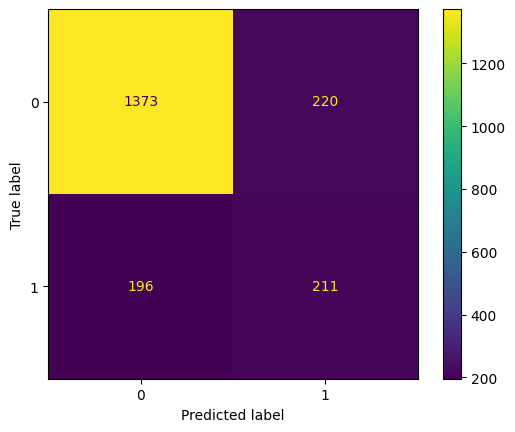

In [20]:
# Build the confusion matrix

confMtrx = confusion_matrix(results['real_values'],results['model_predictions'],labels=decisionTreeModel.classes_)
confMtrxDisp = ConfusionMatrixDisplay(confusion_matrix=confMtrx,display_labels=decisionTreeModel.classes_)

confMtrxDisp.plot()

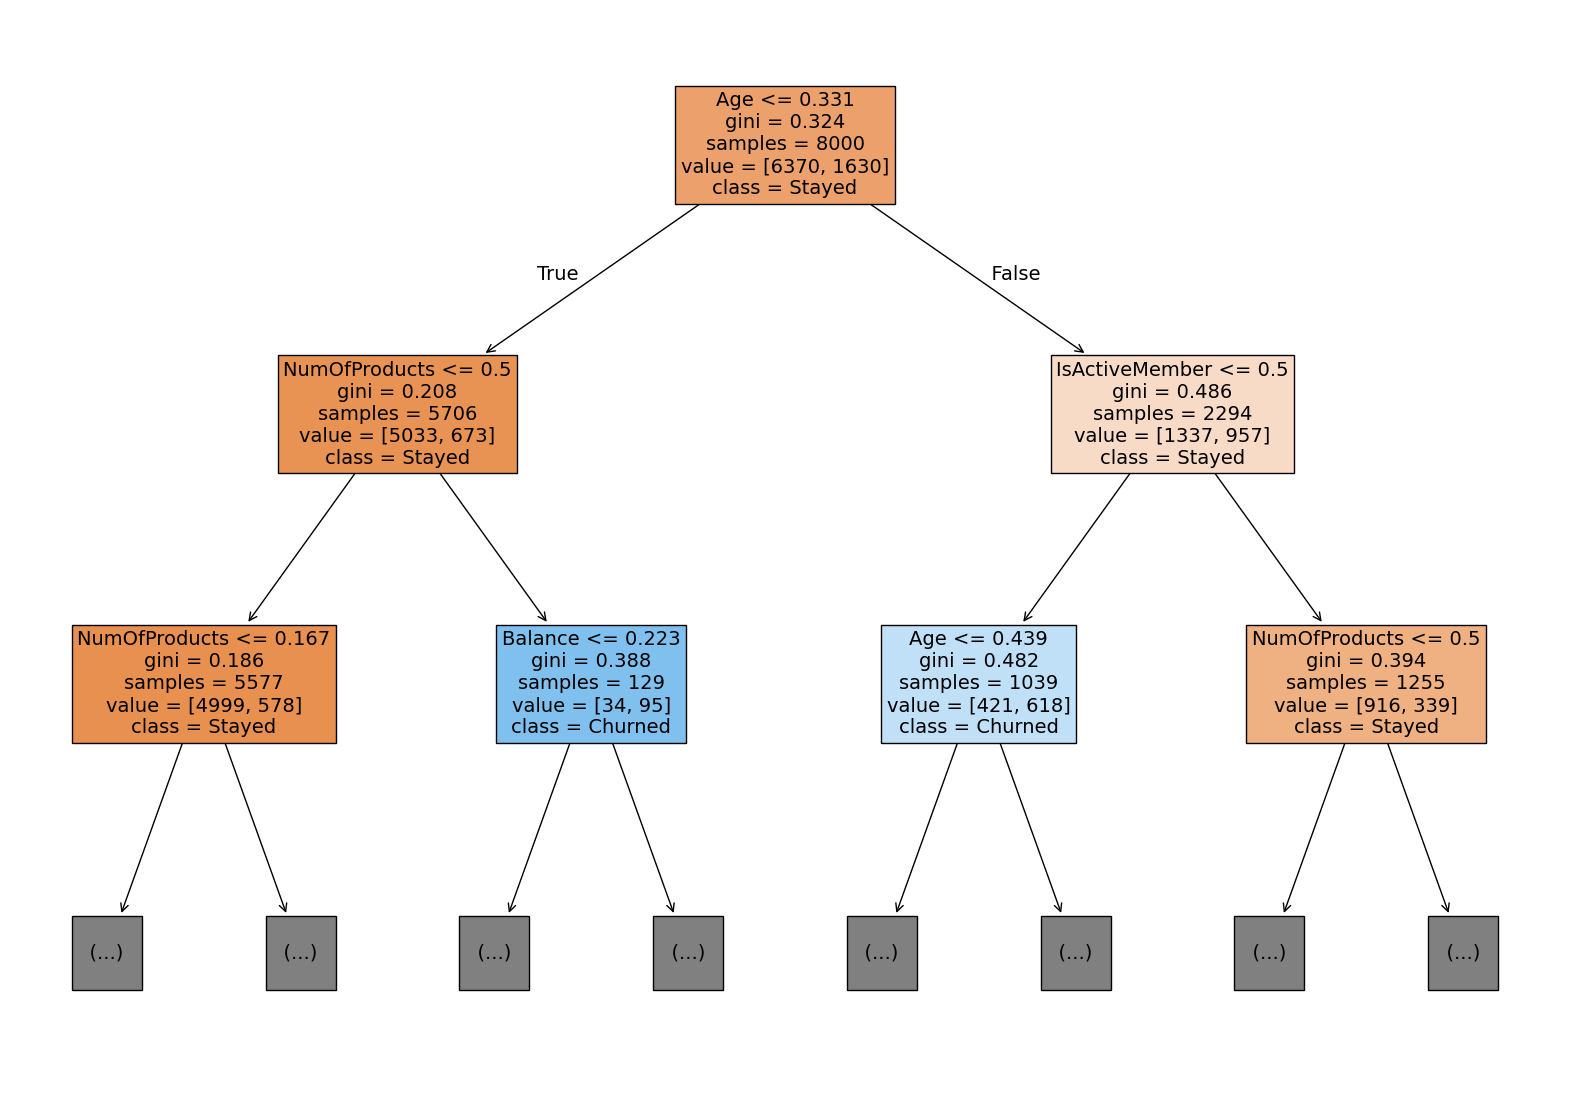

In [24]:
# PLot the tree

plt.figure(figsize=(20,14))

plot_tree(decisionTreeModel,max_depth=2,feature_names=x_norm_df.columns,fontsize=14,
          class_names={0:'Stayed',1:'Churned'},filled=True)

plt.show()

## Tune amd Valid Decision Tree Model

In [25]:
from sklearn.model_selection import GridSearchCV

In [32]:
# Search over hyperparameters defined by a dict

treeHyperParams = {
    'max_depth': [4,5,6,7,8,9,10,11,12,15,20,30,40,50],
    'min_samples_leaf': [2,5,10,20,50]
}

# Create a set with the metrics
metrics = {'accuracy','precision','recall','f1'}

# Create an instance of the model
DecisionTreeM = DecisionTreeClassifier(random_state=42)

In [34]:
# Instantiate the GridSearch

clf = GridSearchCV(
    DecisionTreeM,
    param_grid=treeHyperParams,
    scoring="f1",
    cv=5, # The meaning of cross-validation
    refit='f1'
)

clf.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 5, ...], 'min_samples_leaf': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [35]:
clf.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [37]:
# The best_score_ attribute 
# returns the best average F1 score across the different folds among all the combinations of hyperparameters.
best_scr = clf.best_score_
print(f"The best avg. validation score: {best_scr:.4f}")

The best avg. validation score: 0.5631


In [50]:
# transfor the model results in a df 
cross_validations = pd.DataFrame(clf.cv_results_)

cross_validations.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.026752,0.027547,0.004750,0.000673,4,2,"{'max_depth': 4, 'min_samples_leaf': 2}",0.492693,0.497854,0.452026,0.471311,0.541414,0.491060,0.029994,69
1,0.012831,0.000526,0.003974,0.000196,4,5,"{'max_depth': 4, 'min_samples_leaf': 5}",0.495833,0.497854,0.452026,0.474438,0.544355,0.492901,0.030634,67
2,0.012636,0.000376,0.003855,0.000043,4,10,"{'max_depth': 4, 'min_samples_leaf': 10}",0.501035,0.488121,0.452026,0.474438,0.543260,0.491776,0.030431,68
3,0.012608,0.000236,0.003881,0.000028,4,20,"{'max_depth': 4, 'min_samples_leaf': 20}",0.483193,0.488121,0.453390,0.473469,0.543260,0.488287,0.029951,70
4,0.012451,0.000277,0.003871,0.000047,4,50,"{'max_depth': 4, 'min_samples_leaf': 50}",0.497217,0.549407,0.461840,0.483810,0.528226,0.504100,0.031240,59


In [52]:
# Look up for the model with best F1 score

best_model_f1 = cross_validations['mean_test_score'].max()
best_model_config = cross_validations.loc[cross_validations['mean_test_score'] == best_model_f1,:]
best_model_config

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
32,0.024077,0.000402,0.004115,0.000257,10,10,"{'max_depth': 10, 'min_samples_leaf': 10}",0.59727,0.566108,0.497175,0.586847,0.567857,0.563051,0.034955,1
